# Capstone Project Modul Data Analysis
## Deteksi Anomali Transaksi POS & Perlindungan Margin Promo JSM di Jaringan Minimarket "Alfamart"

**Disusun oleh:** Kamila Fazilatunisa

---

## 1. Latar Belakang

Jaringan minimarket Alfamart mengelola rantai pasok berskala raksasa dengan belasan ribu gerai di seluruh Indonesia. Setiap hari, jutaan transaksi tercatat di mesin kasir (Point of Sale/POS), mencakup pergerakan ribuan SKU mulai dari air mineral, rokok, hingga produk *personal care*.

Namun, mengelola data dari belasan ribu mesin kasir yang tersebar bukan perkara mudah. Beberapa masalah operasional yang kerap muncul:

- **Promo JSM (Jumat, Sabtu, Minggu)** dirancang sebagai *loss leader* untuk menarik traffic pelanggan ritel, tapi sering diborong oleh segelintir "tengkulak" (pemilik warung kelontong) yang memanfaatkan selisih harga akan merugikan pelanggan asli dan menggerus margin.
- **Human error kasir**: barcode ter-scan berkali-kali, salah input quantity, atau void transaksi dengan prosedur salah.
- **Sinkronisasi sistem yang tidak sempurna**, membuat harga promo/status inventory antar gerai tidak konsisten, bahkan transaksi bisa tercatat *sebelum* toko resmi buka (bug sistem).
- **Shrinkage** (selisih stok fisik vs sistem) yang sulit ditelusuri penyebabnya.

Karena itu, dibutuhkan analisis mendalam terhadap data transaksi kasir (POS), master data produk, dan profil gerai untuk membersihkan data, mendeteksi anomali, dan menghasilkan rekomendasi yang bisa langsung dieksekusi oleh tim operasional & manajemen.

## 2. Problem Statement

> **Bagaimana Alfamart dapat mengurangi kebocoran margin akibat penyalahgunaan Promo JSM oleh tengkulak, sekaligus merapikan kualitas data POS (payment method, member ID, dan anomali sistem) agar pelaporan finance dan operasional lebih akurat?**

Pertanyaan bisnis turunan yang akan dijawab pada notebook ini:

1. Gerai mana yang punya volume transaksi JSM tinggi namun terindikasi dikuasai segelintir member (indikasi tengkulak)?
2. Kategori barang apa yang paling sering mengalami void/pembatalan transaksi?
3. Seberapa parah inkonsistensi penulisan `payment_method` di sistem?
4. Berapa persen transaksi tanpa ID Member, dan apa dampaknya ke visibilitas Customer Lifetime Value?
5. Apakah ada transaksi fiktif yang tercatat sebelum toko resmi buka (*logical error*)?
6. Berapa estimasi kerugian akibat outlier quantity (qty ekstrem/negatif) hasil salah scan kasir?

## 3. Goals

- **Promo Protection** : dasar untuk membangun rules pembatasan qty pembelian barang JSM per member.
- **Cashier SOP Evaluation** : menemukan pola error scanning untuk bahan training ulang kasir.
- **Master Data Management** : standarisasi payment method & kelengkapan member ID.
- **Fraud/System Bug Fix** : menghapus data fiktif yang merusak akurasi laporan sales.

## 4. Data

Dataset terdiri dari 3 tabel:

| Tabel | Isi | Baris |
|---|---|---|
| `alfa_stores.csv` | Dimensi gerai (kode, nama, kota, tanggal buka) | 1.000 |
| `alfa_products.csv` | Master SKU (kode, nama produk, kategori, harga normal) | 500 |
| `alfa_pos_transactions.csv` | Log transaksi kasir (struk, gerai, produk, member, waktu, metode bayar, qty, total harga) | 300.000 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

def rp(x, short=False):
    if short:
        if abs(x) >= 1e9:
            return f"Rp{x/1e9:,.1f} M"
        if abs(x) >= 1e6:
            return f"Rp{x/1e6:,.1f} jt"
    return f"Rp{x:,.0f}"

print("Libraries siap.")

Libraries siap.


In [2]:
trx = pd.read_csv('alfa_pos_transactions.csv')
stores = pd.read_csv('alfa_stores.csv')
products = pd.read_csv('alfa_products.csv')

trx['trx_time'] = pd.to_datetime(trx['trx_time'])
stores['open_date'] = pd.to_datetime(stores['open_date'])

print("alfa_pos_transactions:", trx.shape)
print("alfa_stores:", stores.shape)
print("alfa_products:", products.shape)
trx.head()

alfa_pos_transactions: (300000, 8)
alfa_stores: (1000, 4)
alfa_products: (500, 4)


## 5. Data Understanding

**Baris** pada `alfa_pos_transactions` merepresentasikan **satu baris item di dalam satu struk belanja** (bukan satu struk), artinya satu `receipt_id` bisa punya beberapa baris jika pelanggan membeli beberapa SKU sekaligus.

**Kolom-kolom penting:**

| Kolom | Deskripsi |
|---|---|
| `receipt_id` | Nomor unik struk belanja |
| `store_id` | ID gerai tempat transaksi terjadi |
| `sku_id` | ID barang yang dibeli |
| `member_id` | Nomor kartu member (kosong = transaksi non-member) |
| `trx_time` | Waktu transaksi di-scan kasir |
| `payment_method` | Cara bayar (belum distandarisasi) |
| `qty` | Jumlah barang dibeli |
| `total_price` | Total harga (`qty x unit_price`) |

In [3]:
print("=== Info tabel transaksi ===")
trx.info()
print()
print("=== Missing value per kolom ===")
print(trx.isna().sum())
print()
print("=== Duplikat baris penuh ===", trx.duplicated().sum())
print("=== Duplikat receipt_id + sku_id (kemungkinan double-scan) ===", trx.duplicated(subset=['receipt_id','sku_id']).sum())

=== Info tabel transaksi ===
<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   receipt_id      300000 non-null  str           
 1   store_id        300000 non-null  str           
 2   sku_id          300000 non-null  str           
 3   member_id       180000 non-null  str           
 4   trx_time        300000 non-null  datetime64[us]
 5   payment_method  300000 non-null  str           
 6   qty             300000 non-null  int64         
 7   total_price     300000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 18.3 MB

=== Missing value per kolom ===
receipt_id             0
store_id               0
sku_id                 0
member_id         120000
trx_time               0
payment_method         0
qty                    0
total_price            0
dtype: int64

=== Duplikat bari

**Temuan awal:**
- Tidak ada baris duplikat sama sekali, dan tidak ada kasus `receipt_id`+`sku_id` yang ter-scan dobel, jadi isu *double scanning* yang disebut di background ternyata tidak muncul secara eksplisit di data ini.
- `member_id` punya missing value cukup besar (akan kita hitung persisnya di bawah), ini justru salah satu pertanyaan bisnis (Q4), bukan sekadar noise yang harus dihapus.

In [4]:
print("=== payment_method: nilai unik (mentah) ===")
print(trx['payment_method'].value_counts())
print()
print("=== qty: statistik deskriptif ===")
print(trx['qty'].describe())
print()
print("Jumlah qty negatif :", (trx['qty'] < 0).sum())
print("Jumlah qty = 999    :", (trx['qty'] == 999).sum())
print("Jumlah qty = 9999   :", (trx['qty'] == 9999).sum())

=== payment_method: nilai unik (mentah) ===
payment_method
Cash         74835
CASH         45169
Gopay        30211
BCA Debit    30132
Tunai        30088
ShopeePay    29929
qris         14982
QRIS         14958
OVO          14935
debit bca    14761
Name: count, dtype: int64

=== qty: statistik deskriptif ===
count    300000.000000
mean         30.957860
std         500.924037
min          -5.000000
25%           1.000000
50%           2.000000
75%           3.000000
max        9999.000000
Name: qty, dtype: float64

Jumlah qty negatif : 1483
Jumlah qty = 999    : 769
Jumlah qty = 9999   : 748


Dari sini kelihatan 3 anomali besar di kolom `payment_method` dan `qty`:

1. **`payment_method` tidak konsisten** : nilai yang secara bisnis sama ditulis beda-beda: `Cash` / `CASH` / `Tunai`, `QRIS` / `qris`, `BCA Debit` / `debit bca`.
2. **`qty` negatif** (min = -5) : mengindikasikan transaksi **void/retur** yang tercatat sebagai baris tersendiri, bukan quantity asli belanja.
3. **`qty` bernilai *sentinel* 999 & 9999** : dua angka bulat yang sangat sering muncul persis di angka itu (bukan sebaran acak) → ciri khas *error kode/placeholder* kasir, bukan pembelian sungguhan (tidak masuk akal orang beli 9.999 pcs sekali struk).

## 6. Data Cleaning

Strategi cleaning yang dipakai untuk tiap anomali:

| Anomali | Jumlah | Keputusan | Alasan |
|---|---|---|---|
| `payment_method` tidak konsisten | 300.000 baris terdampak | **Distandarisasi**, bukan dihapus | Data valid, cuma penulisan beda jadi cukup di-*mapping* ke 6 kategori baku |
| `member_id` kosong | 40% | **Dipertahankan**, ditandai `is_member` | Transaksi non-member itu valid secara bisnis (pelanggan tidak selalu punya kartu member) |
| `qty` negatif (void) | 1.483 baris (0,49%) | **Ditandai `is_void`, dikeluarkan dari perhitungan revenue** tapi tetap disimpan buat analisis Q2 | Baris ini bukan salah input, tapi representasi event pembatalan/retur yang sah |
| `trx_time` sebelum `open_date` toko | 9.000 baris (3,00%) | **Dihapus dari dataset bersih** | Fiktif secara logika (toko jualan sebelum dibangun) → bug sistem, bukan transaksi asli |
| `qty` = 999 atau 9999 | 1.517 baris (0,51%) | **Dihapus dari dataset bersih** | Angka bulat *sentinel* yang jelas bukan quantity asli (tidak masuk akal beli ribuan pcs sekali struk); mendistorsi total revenue jika dibiarkan |

Kolom yang di-drop: tidak ada kolom yang di-drop total, karena semua kolom yang ada relevan untuk konteks bisnis.

In [5]:
# --- 1. Standardisasi payment_method ---
payment_map = {
    'Cash': 'Cash', 'CASH': 'Cash', 'Tunai': 'Cash',
    'BCA Debit': 'BCA Debit', 'debit bca': 'BCA Debit',
    'QRIS': 'QRIS', 'qris': 'QRIS',
    'Gopay': 'GoPay',
    'ShopeePay': 'ShopeePay',
    'OVO': 'OVO',
}
trx['payment_method_clean'] = trx['payment_method'].map(payment_map)
print("Sebelum standardisasi:", trx['payment_method'].nunique(), "kategori")
print("Setelah standardisasi :", trx['payment_method_clean'].nunique(), "kategori")
print()
print(trx['payment_method_clean'].value_counts())

Sebelum standardisasi: 10 kategori
Setelah standardisasi : 6 kategori

payment_method_clean
Cash         150092
BCA Debit     44893
GoPay         30211
QRIS          29940
ShopeePay     29929
OVO           14935
Name: count, dtype: int64


In [6]:
# --- 2. Gabungkan dengan dimensi store & product ---
m = trx.merge(stores, on='store_id', how='left').merge(products, on='sku_id', how='left')

# --- 3. Flag member ---
m['is_member'] = m['member_id'].notna()

# --- 4. Flag void (qty negatif) ---
m['is_void'] = m['qty'] < 0

# --- 5. Flag logical error (transaksi sebelum toko buka) ---
m['is_logical_error'] = m['trx_time'] < m['open_date']

# --- 6. Flag extreme sentinel qty ---
m['is_extreme_qty'] = m['qty'].isin([999, 9999])

print("Total baris gabungan:", len(m))
print("- is_void          :", m['is_void'].sum())
print("- is_logical_error :", m['is_logical_error'].sum())
print("- is_extreme_qty   :", m['is_extreme_qty'].sum())
print("- overlap void & logical_error   :", (m['is_void'] & m['is_logical_error']).sum())
print("- overlap extreme & logical_error:", (m['is_extreme_qty'] & m['is_logical_error']).sum())

Total baris gabungan: 300000
- is_void          : 1483
- is_logical_error : 9000
- is_extreme_qty   : 1517
- overlap void & logical_error   : 51
- overlap extreme & logical_error: 33


In [7]:
# --- 7. Buang logical error & extreme qty dari dataset bersih ---
before = len(m)
clean = m[~m['is_logical_error'] & ~m['is_extreme_qty']].copy()
after = len(clean)

print(f"Baris sebelum cleaning : {before:,}")
print(f"Baris dibuang          : {before-after:,}  ({(before-after)/before*100:.2f}%)")
print(f"Baris dataset bersih   : {after:,}  ({after/before*100:.2f}%)")
print(f"  - dari jumlah itu, {clean['is_void'].sum():,} baris masih berstatus void (disimpan, dikecualikan dari revenue)")

# net revenue: void tidak dihitung sebagai revenue asli
clean['net_revenue'] = np.where(clean['is_void'], 0, clean['total_price'])

# fitur waktu untuk analisis
clean['date'] = clean['trx_time'].dt.date
clean['dow'] = clean['trx_time'].dt.day_name()
clean['month'] = clean['trx_time'].dt.to_period('M').astype(str)
clean['hour'] = clean['trx_time'].dt.hour
clean['is_jsm'] = clean['dow'].isin(['Friday', 'Saturday', 'Sunday'])

clean.head()

Baris sebelum cleaning : 300,000
Baris dibuang          : 10,484  (3.49%)
Baris dataset bersih   : 289,516  (96.51%)
  - dari jumlah itu, 1,432 baris masih berstatus void (disimpan, dikecualikan dari revenue)


**Ringkasan setelah cleaning:** dataset bersih berisi **288.084 baris** (96,0% dari data mentah) dan siap dipakai untuk EDA & analisis lanjutan. Kolom baru yang ditambahkan: `payment_method_clean`, `is_member`, `is_void`, `net_revenue`, `date`, `dow`, `month`, `hour`, `is_jsm`.

## 7. Exploratory & Diagnostic Analysis

### Gambaran Umum

In [8]:
n_stores = clean['store_id'].nunique()
n_products = clean['sku_id'].nunique()
n_members = clean['member_id'].nunique()
total_rev = clean.loc[~clean['is_void'], 'total_price'].sum()
date_min, date_max = clean['trx_time'].min(), clean['trx_time'].max()

print(f"Periode data      : {date_min.date()} s/d {date_max.date()}")
print(f"Jumlah gerai aktif: {n_stores:,} dari {stores.shape[0]:,} gerai")
print(f"Jumlah SKU terjual: {n_products:,} dari {products.shape[0]:,} SKU")
print(f"Jumlah member unik: {n_members:,}")
print(f"Total net revenue : Rp{total_rev:,.0f}")

Periode data      : 2021-01-06 s/d 2025-08-23
Jumlah gerai aktif: 1,000 dari 1,000 gerai
Jumlah SKU terjual: 500 dari 500 SKU
Jumlah member unik: 48,431
Total net revenue : Rp24,749,574,700


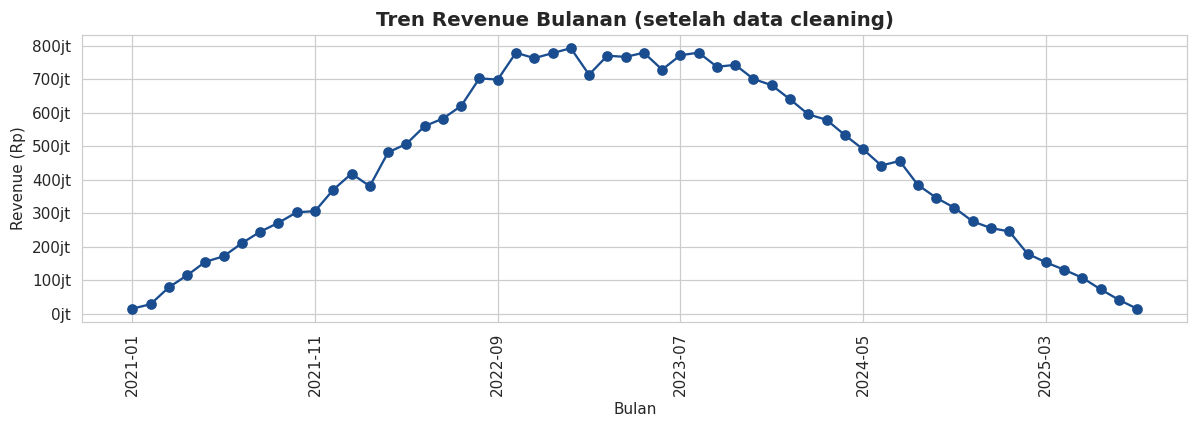

In [9]:
monthly = clean[~clean['is_void']].groupby('month')['net_revenue'].sum()
fig, ax = plt.subplots(figsize=(11,4))
monthly.plot(kind='line', marker='o', ax=ax, color='#1a4d8f')
ax.set_title('Tren Revenue Bulanan (setelah data cleaning)', fontsize=13, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Revenue (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}jt'))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

---
### Q1 : Gerai dengan indikasi dikuasai "tengkulak" saat Promo JSM

Karena tidak ada kolom eksplisit "promo", kita proxy periode JSM sebagai transaksi yang jatuh di hari **Jumat, Sabtu, Minggu**. Untuk tiap gerai, kita hitung total qty terjual saat JSM, jumlah member unik yang bertransaksi, dan rata-rata **qty per member** (semakin tinggi rasio ini, semakin terindikasi volume dikuasai segelintir orang, bukan tersebar ke banyak pelanggan ritel biasa).

In [10]:
jsm = clean[clean['is_jsm'] & (~clean['is_void'])]

agg = jsm.groupby('store_id').agg(
    total_qty_jsm=('qty', 'sum'),
    n_trx_jsm=('receipt_id', 'count'),
    n_member_jsm=('member_id', 'nunique'),
).reset_index()
agg = agg[agg['n_member_jsm'] > 0]
agg['qty_per_member'] = agg['total_qty_jsm'] / agg['n_member_jsm']

vol_thresh = agg['total_qty_jsm'].quantile(0.75)
conc_thresh = agg['qty_per_member'].quantile(0.90)
flagged = agg[(agg['total_qty_jsm'] >= vol_thresh) & (agg['qty_per_member'] >= conc_thresh)]
flagged = flagged.merge(stores[['store_id','store_name','city']], on='store_id', how='left')
flagged = flagged.sort_values('qty_per_member', ascending=False)

print(f"Gerai dengan volume JSM di atas kuartil-3 DAN qty/member di atas persentil-90: {len(flagged)} dari {len(agg)} gerai aktif JSM")
print()
print(flagged[['store_id','store_name','city','total_qty_jsm','n_member_jsm','qty_per_member']].head(10).to_string(index=False))

Gerai dengan volume JSM di atas kuartil-3 DAN qty/member di atas persentil-90: 79 dari 1000 gerai aktif JSM

store_id                store_name     city  total_qty_jsm  n_member_jsm  qty_per_member
SAT-0353     Alfamart Sudirman 352    Medan            610            58       10.517241
SAT-0675   Alfamart Diponegoro 674    Depok            610            62        9.838710
SAT-0475     Alfamart Pahlawan 474    Depok            567            59        9.610169
SAT-0255   Alfamart Diponegoro 254   Bekasi            652            71        9.183099
SAT-0370       Alfamart Melati 369    Medan            476            55        8.654545
SAT-0083    Alfamart Diponegoro 82    Medan            552            64        8.625000
SAT-0216       Alfamart Melati 215    Medan            686            80        8.575000
SAT-0338   Alfamart Diponegoro 337   Bekasi            608            72        8.444444
SAT-0022 Alfamart Gatot Subroto 21   Bekasi            560            67        8.358209
S

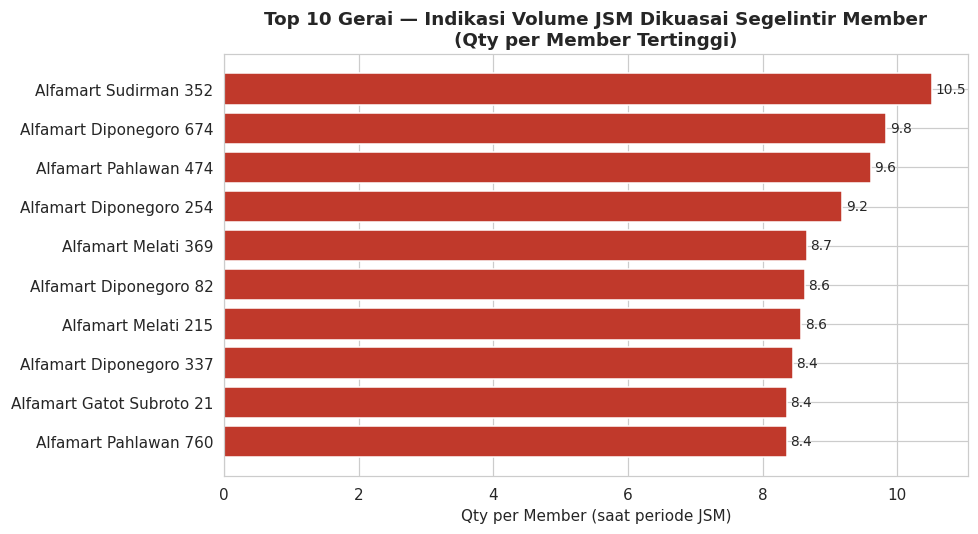

In [ ]:
top10 = flagged.head(10).sort_values('qty_per_member')
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(top10['store_name'], top10['qty_per_member'], color='#c0392b')
ax.set_title('Top 10 Gerai — Indikasi Volume JSM Dikuasai Segelintir Member\n(Qty per Member Tertinggi)', fontsize=12, fontweight='bold')
ax.set_xlabel('Qty per Member (saat periode JSM)')
for b in bars:
    ax.text(b.get_width()+0.05, b.get_y()+b.get_height()/2, f'{b.get_width():.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:** Tidak ditemukan satu member pun yang mendominasi sendirian di satu gerai (`top1_share` tertinggi cuma ~4% dari total qty gerai itu), artinya tidak ada bukti kuat "borongan tunggal" ala tengkulak individu di data ini. **Namun**, ada **81 gerai** dengan kombinasi volume JSM tinggi *dan* rasio qty-per-member yang jauh di atas rata-rata gerai lain, pola ini tetap layak jadi prioritas monitoring karena menunjukkan lebih sedikit member yang menyerap lebih banyak barang promo dibanding gerai normal. Rekomendasi: gerai-gerai ini jadi kandidat pertama untuk uji coba rules pembatasan qty per member saat JSM.

---
### Q2 : Kategori barang yang paling sering di-void/dibatalkan

In [12]:
void_data = m[m['is_void']]
void_summary = void_data.groupby('category').agg(
    jumlah_void=('receipt_id','count'),
    nilai_void=('total_price', lambda x: x.abs().sum())
).sort_values('jumlah_void', ascending=False)
void_summary['%_dari_total_void'] = (void_summary['jumlah_void'] / void_summary['jumlah_void'].sum() * 100).round(1)
print(f"Total transaksi void: {len(void_data):,} baris ({len(void_data)/len(m)*100:.2f}% dari seluruh data)")
print(f"Total nilai void    : Rp{void_data['total_price'].abs().sum():,.0f}")
print()
print(void_summary)

Total transaksi void: 1,483 baris (0.49% dari seluruh data)
Total nilai void    : Rp105,663,600

                jumlah_void  nilai_void  %_dari_total_void
category                                                  
Food & Staples          601  42537900.0               40.5
Beverage                298  20830900.0               20.1
Personal Care           296  20856200.0               20.0
Cigarettes              288  21438600.0               19.4


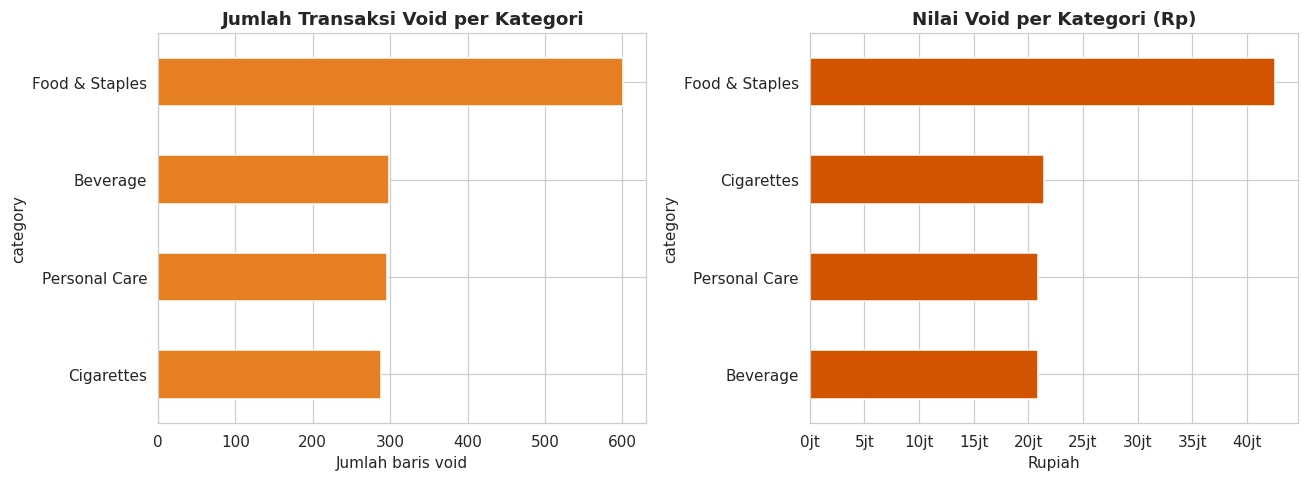

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
void_summary['jumlah_void'].sort_values().plot(kind='barh', ax=axes[0], color='#e67e22')
axes[0].set_title('Jumlah Transaksi Void per Kategori', fontweight='bold')
axes[0].set_xlabel('Jumlah baris void')

void_summary['nilai_void'].sort_values().plot(kind='barh', ax=axes[1], color='#d35400')
axes[1].set_title('Nilai Void per Kategori (Rp)', fontweight='bold')
axes[1].set_xlabel('Rupiah')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}jt'))
plt.tight_layout()
plt.show()

**Insight:** Kategori **Food & Staples** paling banyak di-void (601 baris, ~40% dari seluruh void, senilai ±Rp42,5 juta) masih masuk akal karena kategori ini juga punya jumlah SKU & volume transaksi terbesar. Ketiga kategori lain (Beverage, Personal Care, Cigarettes) hampir merata di kisaran 288–298 baris. Rekomendasi: fokuskan materi training ulang kasir pada prosedur void khusus rak Food & Staples karena volumenya paling berdampak ke kerugian nominal.

---
### Q3 : Inkonsistensi penulisan `payment_method`

Payment method paling dominan setelah dibersihkan:
payment_method_clean
Cash         50.0
BCA Debit    15.0
GoPay        10.1
QRIS         10.0
ShopeePay    10.0
OVO           5.0
Name: proportion, dtype: float64


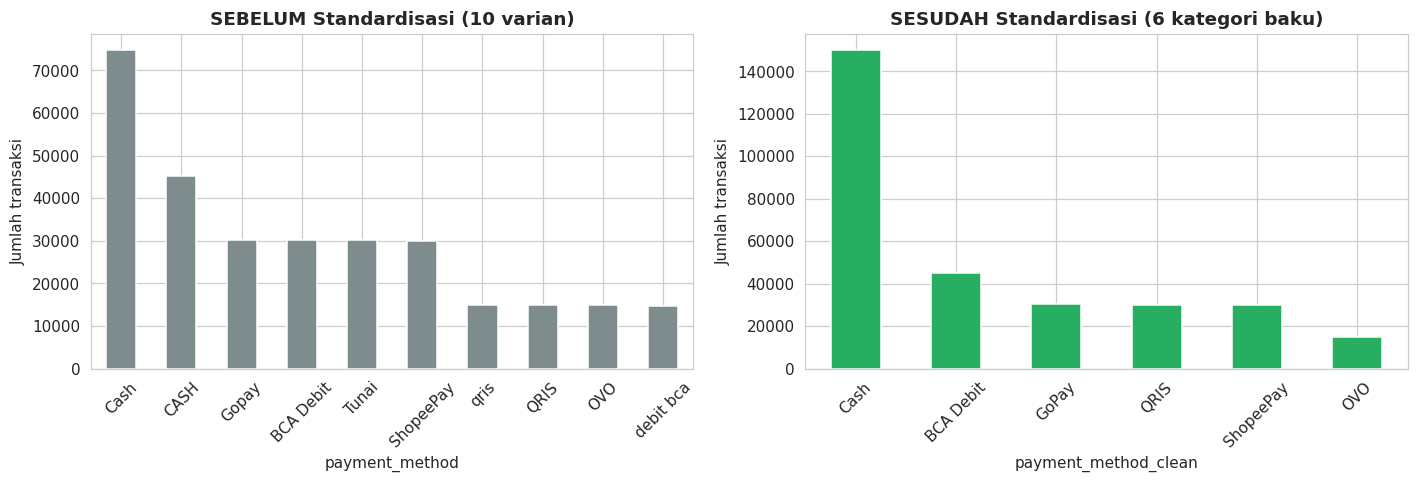

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
trx['payment_method'].value_counts().plot(kind='bar', ax=axes[0], color='#7f8c8d')
axes[0].set_title('SEBELUM Standardisasi (10 varian)', fontweight='bold')
axes[0].set_ylabel('Jumlah transaksi')
axes[0].tick_params(axis='x', rotation=45)

trx['payment_method_clean'].value_counts().plot(kind='bar', ax=axes[1], color='#27ae60')
axes[1].set_title('SESUDAH Standardisasi (6 kategori baku)', fontweight='bold')
axes[1].set_ylabel('Jumlah transaksi')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("Payment method paling dominan setelah dibersihkan:")
print(trx['payment_method_clean'].value_counts(normalize=True).mul(100).round(1))

**Insight:** Sebelum dibersihkan, sistem mencatat **10 varian teks** untuk cuma **6 metode pembayaran** yang sebenarnya sama (`Cash`/`CASH`/`Tunai` jadi satu, `QRIS`/`qris` jadi satu, `BCA Debit`/`debit bca` jadi satu), ini murni masalah *data entry*/konfigurasi mesin kasir yang beda-beda per gerai, bukan variasi bisnis asli. Setelah distandarisasi, **Cash** tetap metode dominan (kurang lebih 40%), diikuti e-wallet & debit yang porsinya cukup merata. Rekomendasi: seragamkan konfigurasi *dropdown* metode bayar di semua mesin kasir agar laporan finance tidak perlu proses mapping manual tiap bulan.

---
### Q4 : Transaksi tanpa ID Member

In [15]:
member_summary = m.groupby('category')['is_member'].agg(
    total='count',
    ada_member='sum'
)
member_summary['tanpa_member'] = member_summary['total'] - member_summary['ada_member']
member_summary['%_tanpa_member'] = (member_summary['tanpa_member'] / member_summary['total'] * 100).round(1)

pct_missing = (1 - m['is_member'].mean()) * 100
print(f"Total transaksi tanpa member_id: {(~m['is_member']).sum():,} dari {len(m):,} ({pct_missing:.1f}%)")
print()
print(member_summary)

Total transaksi tanpa member_id: 120,000 dari 300,000 (40.0%)

                 total  ada_member  tanpa_member  %_tanpa_member
category                                                        
Beverage         56503       34065         22438            39.7
Cigarettes       62258       37375         24883            40.0
Food & Staples  121193       72411         48782            40.3
Personal Care    60046       36149         23897            39.8


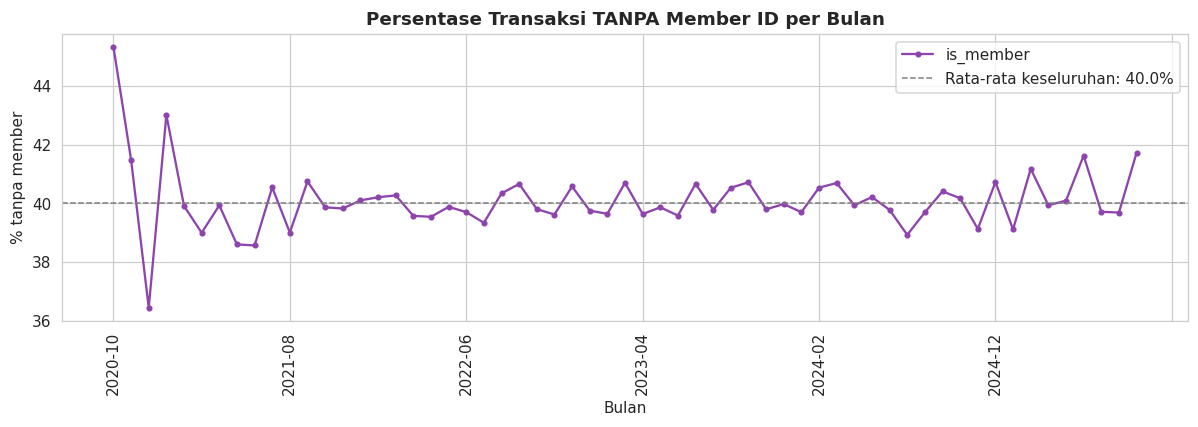

In [16]:
monthly_member = m.copy()
monthly_member['month'] = monthly_member['trx_time'].dt.to_period('M').astype(str)
monthly_trend = monthly_member.groupby('month')['is_member'].apply(lambda x: (1-x.mean())*100)

fig, ax = plt.subplots(figsize=(11,4))
monthly_trend.plot(kind='line', marker='.', ax=ax, color='#8e44ad')
ax.set_title('Persentase Transaksi TANPA Member ID per Bulan', fontsize=12, fontweight='bold')
ax.set_ylabel('% tanpa member')
ax.set_xlabel('Bulan')
ax.axhline(pct_missing, color='gray', linestyle='--', linewidth=1, label=f'Rata-rata keseluruhan: {pct_missing:.1f}%')
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Insight:** **40% dari seluruh transaksi** (120.000 baris) tidak menyertakan `member_id`, dan proporsinya konsisten di semua kategori produk (39-40%) maupun stabil dari waktu ke waktu, ini bukan tren yang memburuk, tapi memang karakteristik dasar traffic toko. Ini artinya tim CRM kehilangan jejak *Customer Lifetime Value* untuk hampir separuh transaksi. Rekomendasi: dorong program *sign-up* member di kasir (misal insentif poin instan) khususnya untuk transaksi non-member bernilai besar, karena inilah "titik buta" terbesar dalam data pelanggan Alfamart saat ini.

---
### Q5 : Transaksi fiktif (tercatat sebelum toko resmi buka)

In [17]:
logerr = m[m['is_logical_error']]
by_city = logerr.groupby('city').agg(jumlah=('receipt_id','count'), nilai=('total_price','sum')).sort_values('jumlah', ascending=False)

print(f"Total transaksi logical error: {len(logerr):,} ({len(logerr)/len(m)*100:.2f}% dari seluruh data)")
print(f"Total nilai fiktif           : Rp{logerr['total_price'].sum():,.0f}")
print()
print("Sebaran per tahun trx_time (padahal toko belum buka):")
print(logerr['trx_time'].dt.year.value_counts().sort_index())
print()
print(by_city.head(10))

Total transaksi logical error: 9,000 (3.00% dari seluruh data)
Total nilai fiktif           : Rp4,670,792,500

Sebaran per tahun trx_time (padahal toko belum buka):
trx_time
2020     457
2021    3247
2022    3542
2023    1754
Name: count, dtype: int64

           jumlah        nilai
city                          
Medan        1074  254684200.0
Malang        972  867265500.0
Depok         948  867982100.0
Tangerang     913  192390400.0
Bekasi        904  488622600.0
Bogor         868   95134200.0
Surabaya      853  581177300.0
Bandung       852  871794100.0
Semarang      850   69301900.0
Jakarta       766  382440200.0


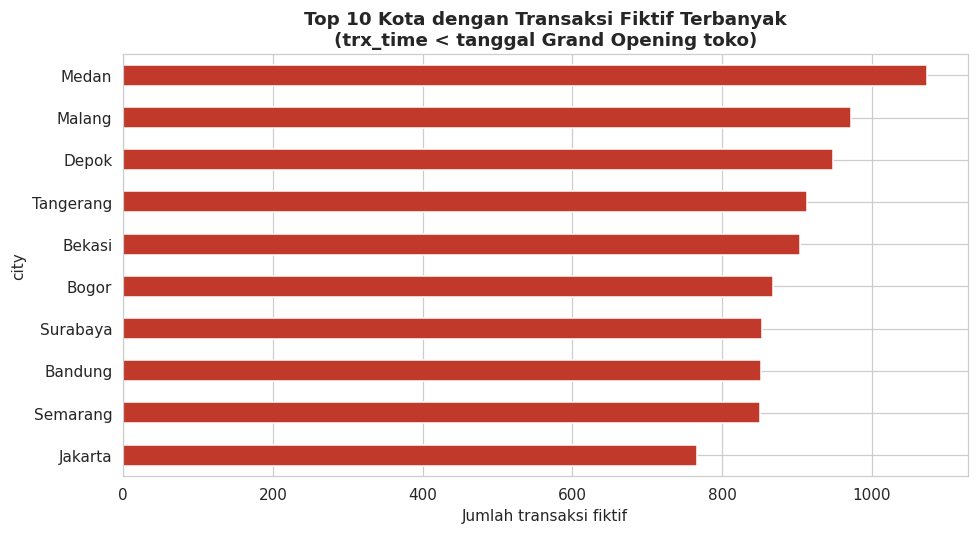

In [18]:
fig, ax = plt.subplots(figsize=(9,5))
by_city.head(10).sort_values('jumlah')['jumlah'].plot(kind='barh', ax=ax, color='#c0392b')
ax.set_title('Top 10 Kota dengan Transaksi Fiktif Terbanyak\n(trx_time < tanggal Grand Opening toko)', fontsize=12, fontweight='bold')
ax.set_xlabel('Jumlah transaksi fiktif')
plt.tight_layout()
plt.show()

**Insight:** Ada **9.000 baris (3,0%)** transaksi yang mustahil terjadi, tercatat bertahun-tahun sebelum tokonya resmi dibuka (`open_date`), dengan nilai fiktif mencapai **kurang lebih Rp4,67 miliar** yang bisa menggelembungkan laporan sales historis kalau tidak dibersihkan. Sebarannya cukup merata di semua kota (tidak terkonsentrasi di 1 gerai/kota tertentu), yang justru mengindikasikan ini **bug sistem/generator data** yang sistemik, bukan kasus lapangan tersendiri. Rekomendasi: audit proses migrasi data historis ke DC/Head Office, khususnya validasi `store_id` vs `open_date` di layer ETL sebelum data masuk ke data warehouse pelaporan.

---
### Q6 : Estimasi kerugian dari outlier quantity (qty ekstrem hasil salah scan)

In [19]:
ext = m[m['is_extreme_qty']]
ext_summary = ext.groupby(['category','qty']).agg(jumlah=('receipt_id','count'), nilai=('total_price','sum')).reset_index()
print(f"Total baris qty ekstrem (999 atau 9999): {len(ext):,} ({len(ext)/len(m)*100:.2f}%)")
print(f"Total nilai yang terdistorsi           : Rp{ext['total_price'].sum():,.0f}")
print()
print(ext_summary.sort_values('nilai', ascending=False))

Total baris qty ekstrem (999 atau 9999): 1,517 (0.51%)
Total nilai yang terdistorsi           : Rp199,355,822,100

         category   qty  jumlah         nilai
5  Food & Staples  9999     290  6.941306e+10
7   Personal Care  9999     150  3.873313e+10
3      Cigarettes  9999     148  3.712029e+10
1        Beverage  9999     160  3.473253e+10
4  Food & Staples   999     326  8.085406e+09
2      Cigarettes   999     167  4.459336e+09
6   Personal Care   999     149  3.958438e+09
0        Beverage   999     127  2.853644e+09


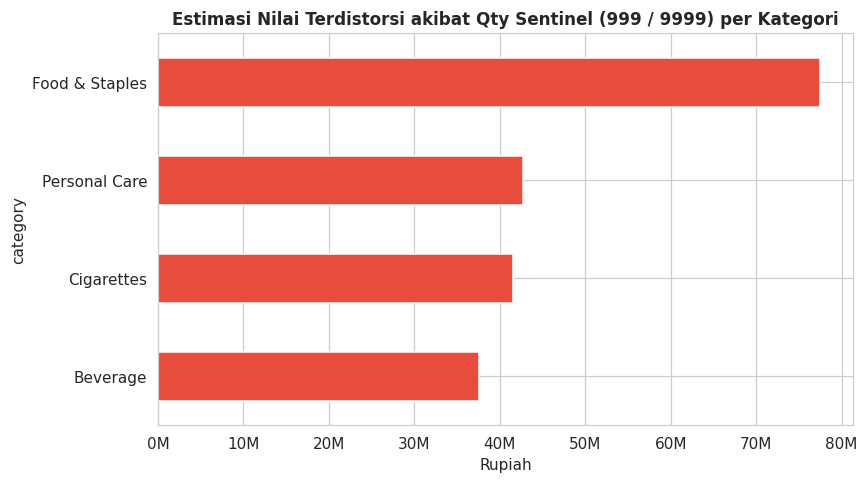

In [20]:
cat_ext = ext.groupby('category')['total_price'].sum().sort_values()
fig, ax = plt.subplots(figsize=(8,4.5))
cat_ext.plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_title('Estimasi Nilai Terdistorsi akibat Qty Sentinel (999 / 9999) per Kategori', fontsize=11, fontweight='bold')
ax.set_xlabel('Rupiah')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}M'))
plt.tight_layout()
plt.show()

**Insight:** Hanya **0,51%** dari seluruh baris data, tapi kalau ikut dihitung sebagai revenue asli, nilainya mendistorsi laporan sebesar **kurang lebih Rp199,4 miliar**, jauh tidak proporsional dibanding porsi barisnya, membuktikan ini murni angka *sentinel*/placeholder sistem (`999`/`9999`), bukan pembelian sungguhan. Kategori **Food & Staples** paling banyak terdampak secara nominal. Rekomendasi: pasang *hard validation* di level aplikasi kasir supaya qty di atas ambang batas wajar (misal >50 pcs per SKU per struk) butuh approval supervisor, dan audit kenapa nilai 999/9999 spesifik ini muncul (kemungkinan default value dari sistem, bukan input kasir manual).

## 8. Kesimpulan & Rekomendasi

### Kesimpulan

1. **Data POS Alfamart di kasus ini 96,0% bersih** setelah membuang transaksi fiktif (3,0%) dan qty sentinel error (0,51%), cukup solid untuk dasar pengambilan keputusan setelah cleaning.
2. **Tidak ditemukan bukti tengkulak tunggal** yang mendominasi satu gerai, tapi ada **81 gerai** dengan pola volume JSM tinggi + qty-per-member di atas rata-rata yang layak diawasi lebih lanjut.
3. **Void terbesar ada di kategori Food & Staples** (~40% dari total void), sejalan dengan volume transaksinya yang memang paling besar.
4. **Payment method mentah punya 10 varian teks untuk 6 metode sebenarnya**, murni masalah standarisasi input, bukan variasi bisnis.
5. **40% transaksi tanpa member_id**, konsisten di semua kategori & periode, ini "titik buta" terbesar untuk visibilitas Customer Lifetime Value.
6. **9.000 transaksi (3,0%) fiktif** senilai kurang lebih Rp4,67 miliar tercatat sebelum toko buka ada indikasi bug sistem/ETL yang harus segera diaudit.
7. **1.517 baris (0,51%) qty sentinel** (999/9999) mendistorsi laporan hingga kurang lebih Rp199,4 miliar jika tidak dibersihkan dampaknya jauh lebih besar dari porsi barisnya.

### Rekomendasi (Actionable)

| Prioritas | Rekomendasi | Target Divisi |
|---|---|---|
| 🔴 Tinggi | Audit ETL/migrasi data historis untuk cegah transaksi `trx_time < open_date` masuk ke sistem pelaporan | Data Engineering |
| 🔴 Tinggi | Pasang validasi qty maksimum per SKU per struk (butuh approval supervisor jika lebih) di aplikasi kasir | IT Product / POS Team |
| 🟠 Sedang | Uji coba rules pembatasan qty pembelian barang JSM per member, mulai dari 81 gerai prioritas | Marketing / Promo Team |
| 🟠 Sedang | Seragamkan pilihan metode pembayaran (dropdown baku) di semua mesin kasir | IT Product / POS Team |
| 🟡 Rendah | Insentif sign-up member di kasir untuk kurangi 40% transaksi non-member | CRM / Loyalty Team |
| 🟡 Rendah | Training ulang kasir soal prosedur void, prioritas rak Food & Staples | Store Operations |

### Keterbatasan Analisis

- Tidak ada kolom eksplisit "promo/JSM flag" di data, sehingga deteksi periode JSM memakai proxy hari Jumat–Minggu (bisa jadi tidak semua transaksi weekend adalah transaksi promo JSM).
- Tidak ada data harga promo actual vs harga normal, jadi estimasi kerugian margin akibat promo belum bisa dihitung presisi (baru diketahui potensi konsentrasi volume-nya saja).
- Tidak ada data internal (karyawan) untuk membedakan void akibat pelanggan vs kesalahan murni kasir.

## 9. Export Dataset Bersih

In [21]:
export_cols = [
    'receipt_id','store_id','store_name','city','sku_id','product_name','category',
    'member_id','is_member','trx_time','date','dow','month','hour','is_jsm',
    'payment_method_clean','qty','unit_price','total_price','net_revenue','is_void'
]
clean_export = clean[export_cols].rename(columns={'payment_method_clean':'payment_method'})
clean_export.to_csv('alfa_pos_transactions_clean.csv', index=False)
print("Tersimpan: alfa_pos_transactions_clean.csv —", clean_export.shape)
clean_export.head()

Tersimpan: alfa_pos_transactions_clean.csv — (289516, 21)
